# **1. Importação das bibliotecas**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances

# **2. Carregamento do dataset**

In [3]:
arquivo = "ventas_carniceria_sucio_4000.csv"

df = pd.read_csv(arquivo)

df.head()

,fecha,tienda,producto,precio,cantidad,total_venta
0,2025-11-25,Carniceria Norte,Res,174.84,11.0,1923.24
1,2025-05-27,Cortes Finos MX,NaN,143.09,19.0,2718.71
2,2025-12-23,La Vaca Feliz,Pollo,634.4399999999999,3.0,1903.32
3,2026-03-03,Super Carnes,Res,NaN,564.0,72975.96
4,2025-11-01,El Torito,Res,151.11,10.0,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4120 entries, 0 to 4119
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   fecha        3998 non-null   object 
 1   tienda       3997 non-null   object 
 2   producto     3997 non-null   object 
 3   precio       4000 non-null   object 
 4   cantidad     3992 non-null   object 
 5   total_venta  3997 non-null   float64
dtypes: float64(1), object(5)
memory usage: 193.3+ KB


In [5]:
df.describe(include="all")

,fecha,tienda,producto,precio,cantidad,total_venta
count,3998,3997,3997,4000,3992,3997.000000
unique,367,5,6,3414,109,NaN
top,2025/99/99,Super Carnes,Chorizo,error,15.0,NaN
freq,61,852,691,61,224,NaN
mean,NaN,NaN,NaN,NaN,NaN,3519.487213
std,NaN,NaN,NaN,NaN,NaN,17449.258458
min,NaN,NaN,NaN,NaN,NaN,-26.760000
25%,NaN,NaN,NaN,NaN,NaN,734.820000
50%,NaN,NaN,NaN,NaN,NaN,1440.790000
75%,NaN,NaN,NaN,NaN,NaN,2321.480000


# **3. Visualização inicial dos dados**

In [6]:
print("Quantidade de linhas e colunas:", df.shape)
print("\nColunas do dataset:")
print(df.columns.tolist())

Quantidade de linhas e colunas: (4120, 6)

Colunas do dataset:
['fecha', 'tienda', 'producto', 'precio', 'cantidad', 'total_venta']


In [7]:
print("Valores nulos por coluna:")
print(df.isnull().sum())

Valores nulos por coluna:
fecha          122
tienda         123
producto       123
precio         120
cantidad       128
total_venta    123
dtype: int64


In [8]:
print("Produtos encontrados:")
print(df["producto"].value_counts(dropna=False))

Produtos encontrados:
producto
Chorizo      691
Pollo        686
Costilla     683
Res          665
Arrachera    639
Cerdo        633
NaN          123
Name: count, dtype: int64


In [9]:
print("Lojas encontradas:")
print(df["tienda"].value_counts(dropna=False))

Lojas encontradas:
tienda
Super Carnes        852
Cortes Finos MX     818
El Torito           794
Carniceria Norte    771
La Vaca Feliz       762
NaN                 123
Name: count, dtype: int64


# **4. Limpeza e preparação dos dados**

In [10]:
# Criando uma cópia para preservar o dataframe original
dados = df.copy()

# Padronizando nomes de colunas, se necessário
dados.columns = dados.columns.str.strip().str.lower()

dados.head()

,fecha,tienda,producto,precio,cantidad,total_venta
0,2025-11-25,Carniceria Norte,Res,174.84,11.0,1923.24
1,2025-05-27,Cortes Finos MX,NaN,143.09,19.0,2718.71
2,2025-12-23,La Vaca Feliz,Pollo,634.4399999999999,3.0,1903.32
3,2026-03-03,Super Carnes,Res,NaN,564.0,72975.96
4,2025-11-01,El Torito,Res,151.11,10.0,NaN


In [11]:
# Conversão de data
dados["fecha"] = pd.to_datetime(dados["fecha"], errors="coerce")

# Conversão das colunas numéricas
dados["precio"] = pd.to_numeric(dados["precio"], errors="coerce")
dados["cantidad"] = pd.to_numeric(dados["cantidad"], errors="coerce")
dados["total_venta"] = pd.to_numeric(dados["total_venta"], errors="coerce")

dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4120 entries, 0 to 4119
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   fecha        3937 non-null   datetime64[ns]
 1   tienda       3997 non-null   object        
 2   producto     3997 non-null   object        
 3   precio       3939 non-null   float64       
 4   cantidad     3932 non-null   float64       
 5   total_venta  3997 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 193.3+ KB


# **5. Tratamento de valores ausentes**

In [12]:
print("Valores nulos antes do tratamento:")
print(dados.isnull().sum())

Valores nulos antes do tratamento:
fecha          183
tienda         123
producto       123
precio         181
cantidad       188
total_venta    123
dtype: int64


In [13]:
# Remover linhas sem data ou sem loja, porque são informações básicas
dados = dados.dropna(subset=["fecha", "tienda"])

# Preencher produto ausente como "Desconhecido"
dados["producto"] = dados["producto"].fillna("Desconhecido")

# Quando preço está ausente, tentar recalcular usando total_venta / cantidad
dados.loc[
    dados["precio"].isnull() & dados["total_venta"].notnull() & dados["cantidad"].notnull() & (dados["cantidad"] != 0),
    "precio"
] = dados["total_venta"] / dados["cantidad"]

# Quando total_venta está ausente, tentar recalcular usando precio * cantidad
dados.loc[
    dados["total_venta"].isnull() & dados["precio"].notnull() & dados["cantidad"].notnull(),
    "total_venta"
] = dados["precio"] * dados["cantidad"]

# Quando quantidade está ausente, tentar recalcular usando total_venta / precio
dados.loc[
    dados["cantidad"].isnull() & dados["total_venta"].notnull() & dados["precio"].notnull() & (dados["precio"] != 0),
    "cantidad"
] = dados["total_venta"] / dados["precio"]

# Remover linhas que ainda ficaram sem variáveis numéricas principais
dados = dados.dropna(subset=["precio", "cantidad", "total_venta"])

# Remover registros com valores negativos ou zero inválidos
dados = dados[
    (dados["precio"] > 0) &
    (dados["cantidad"] > 0) &
    (dados["total_venta"] > 0)
]

print("Valores nulos depois do tratamento:")
print(dados.isnull().sum())

print("\nNovo tamanho do dataset:", dados.shape)

Valores nulos depois do tratamento:
fecha          0
tienda         0
producto       0
precio         0
cantidad       0
total_venta    0
dtype: int64

Novo tamanho do dataset: (3766, 6)


# **6. Criação de variáveis auxiliares**

In [14]:
dados["ano"] = dados["fecha"].dt.year
dados["mes"] = dados["fecha"].dt.month
dados["ano_mes"] = dados["fecha"].dt.to_period("M").astype(str)

dados.head()

,fecha,tienda,producto,precio,cantidad,total_venta,ano,mes,ano_mes
0,2025-11-25,Carniceria Norte,Res,174.84,11.0,1923.24,2025,11,2025-11
1,2025-05-27,Cortes Finos MX,Desconhecido,143.09,19.0,2718.71,2025,5,2025-05
2,2025-12-23,La Vaca Feliz,Pollo,634.44,3.0,1903.32,2025,12,2025-12
3,2026-03-03,Super Carnes,Res,129.39,564.0,72975.96,2026,3,2026-03
4,2025-11-01,El Torito,Res,151.11,10.0,1511.10,2025,11,2025-11


# **7. Análise descritiva inicial**

In [15]:
print("Período analisado:")
print("Data inicial:", dados["fecha"].min())
print("Data final:", dados["fecha"].max())

print("\nQuantidade de lojas:", dados["tienda"].nunique())
print("Quantidade de produtos:", dados["producto"].nunique())
print("Quantidade de registros:", len(dados))

Período analisado:
Data inicial: 2025-04-25 00:00:00
Data final: 2026-04-25 00:00:00

Quantidade de lojas: 5
Quantidade de produtos: 7
Quantidade de registros: 3766


In [16]:
resumo_produtos = dados.groupby("producto").agg(
    quantidade_total=("cantidad", "sum"),
    receita_total=("total_venta", "sum"),
    preco_medio=("precio", "mean"),
    numero_vendas=("producto", "count"),
    lojas_diferentes=("tienda", "nunique"),
    meses_com_venda=("ano_mes", "nunique")
).reset_index()

resumo_produtos["ticket_medio"] = resumo_produtos["receita_total"] / resumo_produtos["numero_vendas"]

resumo_produtos.head()

,producto,quantidade_total,receita_total,preco_medio,numero_vendas,lojas_diferentes,meses_com_venda,ticket_medio
0,Arrachera,12703.0,2684963.86,189.293973,589,5,13,4558.512496
1,Cerdo,8916.0,1554223.54,187.878049,574,5,13,2707.706516
2,Chorizo,9671.0,1683283.04,186.403836,636,5,13,2646.671447
3,Costilla,10645.0,2357888.39,190.432336,625,5,13,3772.621424
4,Desconhecido,2576.0,407805.47,140.094952,105,5,13,3883.861619


# **8. Dataset final para PCA e MDS**

Neste trabalho, cada ponto dos gráficos será um produto do açougue.

In [17]:
features = [
    "quantidade_total",
    "receita_total",
    "preco_medio",
    "numero_vendas",
    "lojas_diferentes",
    "meses_com_venda",
    "ticket_medio"
]

dados_analise = resumo_produtos[["producto"] + features].copy()

dados_analise

,producto,quantidade_total,receita_total,preco_medio,numero_vendas,lojas_diferentes,meses_com_venda,ticket_medio
0,Arrachera,12703.0,2684963.86,189.293973,589,5,13,4558.512496
1,Cerdo,8916.0,1554223.54,187.878049,574,5,13,2707.706516
2,Chorizo,9671.0,1683283.04,186.403836,636,5,13,2646.671447
3,Costilla,10645.0,2357888.39,190.432336,625,5,13,3772.621424
4,Desconhecido,2576.0,407805.47,140.094952,105,5,13,3883.861619
5,Pollo,11833.0,1932176.59,188.179857,630,5,13,3066.946968
6,Res,13093.0,2269407.83,178.718072,607,5,13,3738.727891


In [18]:
print("Quantidade de produtos analisados:", dados_analise.shape[0])
print("Quantidade de features numéricas:", len(features))

Quantidade de produtos analisados: 7
Quantidade de features numéricas: 7


In [19]:
dados_analise.describe()

,quantidade_total,receita_total,preco_medio,numero_vendas,lojas_diferentes,meses_com_venda,ticket_medio
count,7.000000,7.000000e+00,7.000000,7.00000,7.0,7.0,7.000000
mean,9919.571429,1.841393e+06,180.143011,538.00000,5.0,13.0,3482.149766
std,3582.423847,7.452579e+05,18.069806,192.26024,0.0,0.0,700.037498
min,2576.000000,4.078055e+05,140.094952,105.00000,5.0,13.0,2646.671447
25%,9293.500000,1.618753e+06,182.560954,581.50000,5.0,13.0,2887.326742
50%,10645.000000,1.932177e+06,187.878049,607.00000,5.0,13.0,3738.727891
75%,12268.000000,2.313648e+06,188.736915,627.50000,5.0,13.0,3828.241522
max,13093.000000,2.684964e+06,190.432336,636.00000,5.0,13.0,4558.512496


# Remoção de valores ausentes (EXTRA)

In [43]:
dados_analise = dados_analise[dados_analise["producto"] != "Desconhecido"].copy()

# **9. Padronização dos dados**

A padronização é obrigatória aqui porque as variáveis estão em escalas diferentes.

In [44]:
X = dados_analise[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()

,quantidade_total,receita_total,preco_medio,numero_vendas,lojas_diferentes,meses_com_venda,ticket_medio
0,1.017792,1.531876,0.646773,-0.939299,0.0,0.0,1.688160
1,-1.453756,-1.332893,0.276952,-1.604944,0.0,0.0,-1.044645
2,-0.961013,-1.005916,-0.108092,1.146388,0.0,0.0,-1.134766
3,-0.325341,0.703219,0.944099,0.658249,0.0,0.0,0.527753
4,0.449995,-0.375336,0.355781,0.880130,0.0,0.0,-0.514209


# **10. Aplicação do PCA**

In [45]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

dados_analise["PC1"] = X_pca[:, 0]
dados_analise["PC2"] = X_pca[:, 1]

dados_analise.head()

,producto,quantidade_total,receita_total,preco_medio,numero_vendas,lojas_diferentes,meses_com_venda,ticket_medio,PC1,PC2,distancia_pca,MDS1,MDS2,distancia_mds
0,Arrachera,12703.0,2684963.86,189.293973,589,5,13,4558.512496,2.451600,1.198681,2.299411,2.171697,-0.820988,2.321699
1,Cerdo,8916.0,1554223.54,187.878049,574,5,13,2707.706516,-2.073868,0.870506,1.371501,-0.776119,1.192634,1.422932
2,Chorizo,9671.0,1683283.04,186.403836,636,5,13,2646.671447,-1.863801,-0.648327,1.465550,-0.449866,1.454461,1.522444
3,Costilla,10645.0,2357888.39,190.432336,625,5,13,3772.621424,0.386450,0.850402,1.115529,1.278006,0.367785,1.329874
5,Pollo,11833.0,1932176.59,188.179857,630,5,13,3066.946968,-0.387860,-0.377579,1.089942,0.388488,1.053130,1.122499


# **11. Variância explicada pelo PCA**

In [46]:
variancia_explicada = pca.explained_variance_ratio_

print("Variância explicada pelo PC1:", round(variancia_explicada[0] * 100, 2), "%")
print("Variância explicada pelo PC2:", round(variancia_explicada[1] * 100, 2), "%")
print("Variância explicada acumulada:", round(variancia_explicada.sum() * 100, 2), "%")

Variância explicada pelo PC1: 54.32 %
Variância explicada pelo PC2: 23.56 %
Variância explicada acumulada: 77.88 %


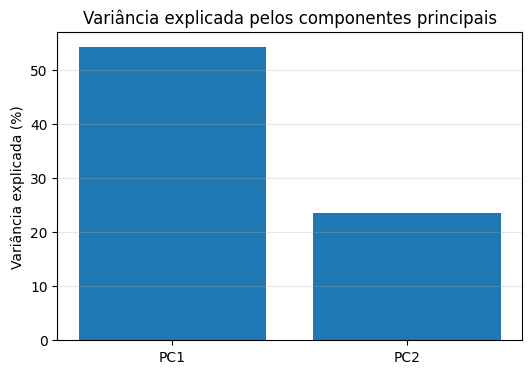

In [47]:
plt.figure(figsize=(6, 4))
plt.bar(["PC1", "PC2"], variancia_explicada * 100)
plt.ylabel("Variância explicada (%)")
plt.title("Variância explicada pelos componentes principais")
plt.grid(axis="y", alpha=0.3)
plt.show()

# **12. Gráfico PCA em 2D**

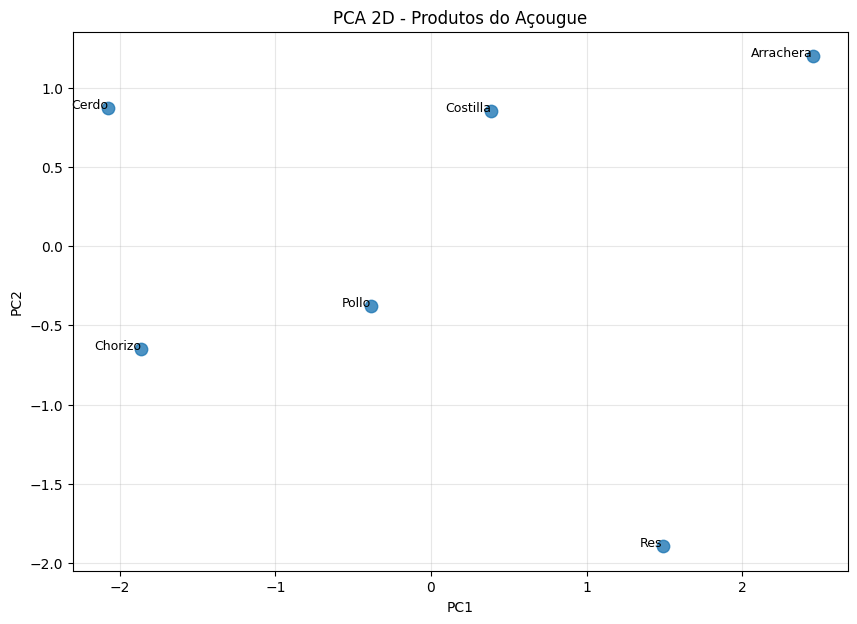

In [48]:
plt.figure(figsize=(10, 7))

plt.scatter(
    dados_analise["PC1"],
    dados_analise["PC2"],
    s=80,
    alpha=0.8
)

for i, produto in enumerate(dados_analise["producto"]):
    plt.text(
        dados_analise["PC1"].iloc[i],
        dados_analise["PC2"].iloc[i],
        produto,
        fontsize=9,
        ha="right"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D - Produtos do Açougue")
plt.grid(True, alpha=0.3)
plt.show()

# **13. Contribuição das variáveis no PCA**

In [49]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

loadings

,PC1,PC2
quantidade_total,0.545703,-0.322412
receita_total,0.584421,0.164244
preco_medio,-0.104753,0.815240
numero_vendas,-0.086333,-0.392360
lojas_diferentes,0.000000,-0.000000
meses_com_venda,0.000000,-0.000000
ticket_medio,0.585008,0.224747


In [50]:
print("Variáveis que mais influenciam o PC1:")
display(loadings["PC1"].abs().sort_values(ascending=False))

print("\nVariáveis que mais influenciam o PC2:")
display(loadings["PC2"].abs().sort_values(ascending=False))

Variáveis que mais influenciam o PC1:


,PC1
ticket_medio,0.585008
receita_total,0.584421
quantidade_total,0.545703
preco_medio,0.104753
numero_vendas,0.086333
lojas_diferentes,0.000000
meses_com_venda,0.000000



Variáveis que mais influenciam o PC2:


,PC2
preco_medio,0.815240
numero_vendas,0.392360
quantidade_total,0.322412
ticket_medio,0.224747
receita_total,0.164244
lojas_diferentes,0.000000
meses_com_venda,0.000000


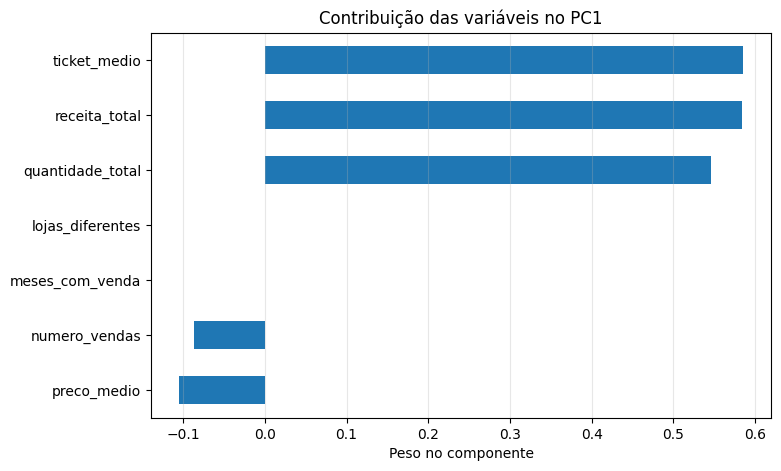

In [51]:
plt.figure(figsize=(8, 5))
loadings["PC1"].sort_values().plot(kind="barh")
plt.title("Contribuição das variáveis no PC1")
plt.xlabel("Peso no componente")
plt.grid(axis="x", alpha=0.3)
plt.show()

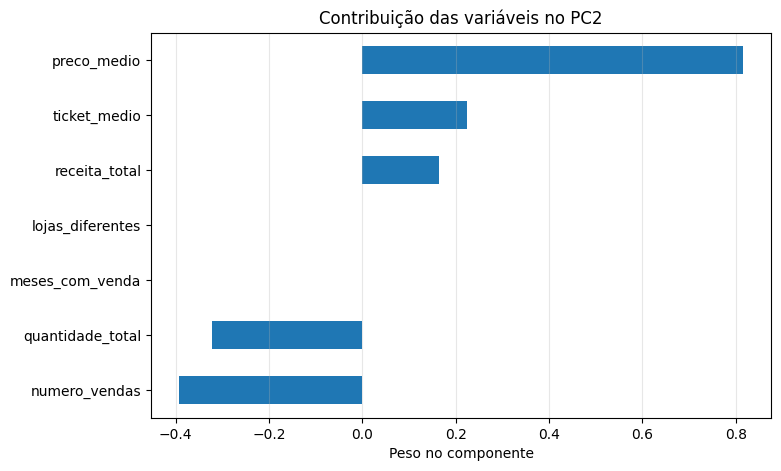

In [52]:
plt.figure(figsize=(8, 5))
loadings["PC2"].sort_values().plot(kind="barh")
plt.title("Contribuição das variáveis no PC2")
plt.xlabel("Peso no componente")
plt.grid(axis="x", alpha=0.3)
plt.show()

# **14. Identificação simples de possíveis outliers no PCA**

Aqui vamos identificar produtos muito distantes do centro do gráfico PCA.

In [53]:
dados_analise["distancia_pca"] = np.sqrt(
    dados_analise["PC1"]**2 + dados_analise["PC2"]**2
)

limite_outlier = dados_analise["distancia_pca"].quantile(0.90)

outliers_pca = dados_analise[dados_analise["distancia_pca"] >= limite_outlier].copy()

outliers_pca = outliers_pca.sort_values("distancia_pca", ascending=False)

outliers_pca[["producto", "distancia_pca"] + features]

,producto,distancia_pca,quantidade_total,receita_total,preco_medio,numero_vendas,lojas_diferentes,meses_com_venda,ticket_medio
0,Arrachera,2.728952,12703.0,2684963.86,189.293973,589,5,13,4558.512496


# **15. Aplicação do MDS**

O MDS usa as distâncias entre os produtos para posicioná-los em duas dimensões.

In [54]:
mds = MDS(
    n_components=2,
    random_state=42,
    normalized_stress="auto",
    dissimilarity="euclidean"
)

X_mds = mds.fit_transform(X_scaled)

dados_analise["MDS1"] = X_mds[:, 0]
dados_analise["MDS2"] = X_mds[:, 1]

dados_analise.head()

,producto,quantidade_total,receita_total,preco_medio,numero_vendas,lojas_diferentes,meses_com_venda,ticket_medio,PC1,PC2,distancia_pca,MDS1,MDS2,distancia_mds
0,Arrachera,12703.0,2684963.86,189.293973,589,5,13,4558.512496,2.451600,1.198681,2.728952,0.348270,2.799212,2.321699
1,Cerdo,8916.0,1554223.54,187.878049,574,5,13,2707.706516,-2.073868,0.870506,2.249157,-2.678821,-1.072857,1.422932
2,Chorizo,9671.0,1683283.04,186.403836,636,5,13,2646.671447,-1.863801,-0.648327,1.973343,-0.224048,-2.148250,1.522444
3,Costilla,10645.0,2357888.39,190.432336,625,5,13,3772.621424,0.386450,0.850402,0.934091,-0.401927,0.798187,1.329874
5,Pollo,11833.0,1932176.59,188.179857,630,5,13,3066.946968,-0.387860,-0.377579,0.541295,0.293099,-0.738303,1.122499


# **16. Gráfico MDS em 2D**

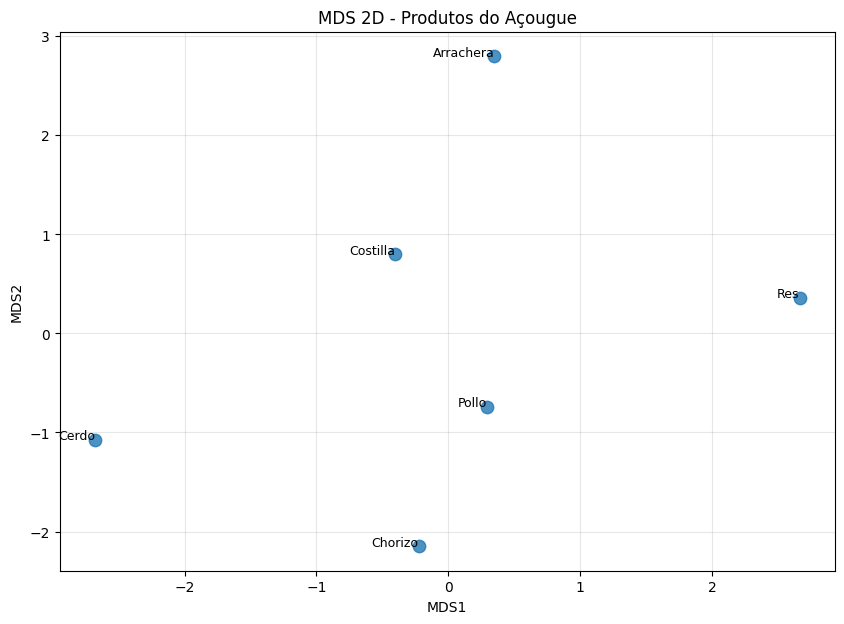

In [55]:
plt.figure(figsize=(10, 7))

plt.scatter(
    dados_analise["MDS1"],
    dados_analise["MDS2"],
    s=80,
    alpha=0.8
)

for i, produto in enumerate(dados_analise["producto"]):
    plt.text(
        dados_analise["MDS1"].iloc[i],
        dados_analise["MDS2"].iloc[i],
        produto,
        fontsize=9,
        ha="right"
    )

plt.xlabel("MDS1")
plt.ylabel("MDS2")
plt.title("MDS 2D - Produtos do Açougue")
plt.grid(True, alpha=0.3)
plt.show()

# **17. Identificação de produtos semelhantes pelo MDS**

In [56]:
distancias = pairwise_distances(
    dados_analise[["MDS1", "MDS2"]],
    metric="euclidean"
)

distancias_df = pd.DataFrame(
    distancias,
    index=dados_analise["producto"],
    columns=dados_analise["producto"]
)

distancias_df.head()

producto,Arrachera,Cerdo,Chorizo,Costilla,Pollo,Res
producto,,,,,,
Arrachera,0.000000,4.914896,4.980455,2.137030,3.537946,3.361532
Cerdo,4.914896,0.000000,2.679997,2.947041,2.990692,5.531588
Chorizo,4.980455,2.679997,0.000000,2.951802,1.501796,3.826085
Costilla,2.137030,2.947041,2.951802,0.000000,1.686376,3.096230
Pollo,3.537946,2.990692,1.501796,1.686376,0.000000,2.613263


In [57]:
pares = []

produtos = dados_analise["producto"].tolist()

for i in range(len(produtos)):
    for j in range(i + 1, len(produtos)):
        pares.append({
            "produto_1": produtos[i],
            "produto_2": produtos[j],
            "distancia_mds": distancias_df.iloc[i, j]
        })

pares_df = pd.DataFrame(pares)

produtos_mais_semelhantes = pares_df.sort_values("distancia_mds").head(10)

produtos_mais_semelhantes

,produto_1,produto_2,distancia_mds
10,Chorizo,Pollo,1.501796
12,Costilla,Pollo,1.686376
2,Arrachera,Costilla,2.137030
14,Pollo,Res,2.613263
5,Cerdo,Chorizo,2.679997
6,Cerdo,Costilla,2.947041
9,Chorizo,Costilla,2.951802
7,Cerdo,Pollo,2.990692
13,Costilla,Res,3.096230
4,Arrachera,Res,3.361532


# **18. Possíveis outliers no MDS**

In [58]:
dados_analise["distancia_mds"] = np.sqrt(
    dados_analise["MDS1"]**2 + dados_analise["MDS2"]**2
)

limite_outlier_mds = dados_analise["distancia_mds"].quantile(0.90)

outliers_mds = dados_analise[dados_analise["distancia_mds"] >= limite_outlier_mds].copy()

outliers_mds = outliers_mds.sort_values("distancia_mds", ascending=False)

outliers_mds[["producto", "distancia_mds"] + features]

,producto,distancia_mds,quantidade_total,receita_total,preco_medio,numero_vendas,lojas_diferentes,meses_com_venda,ticket_medio
1,Cerdo,2.885672,8916.0,1554223.54,187.878049,574,5,13,2707.706516


# **19. Comparação visual entre PCA e MDS**

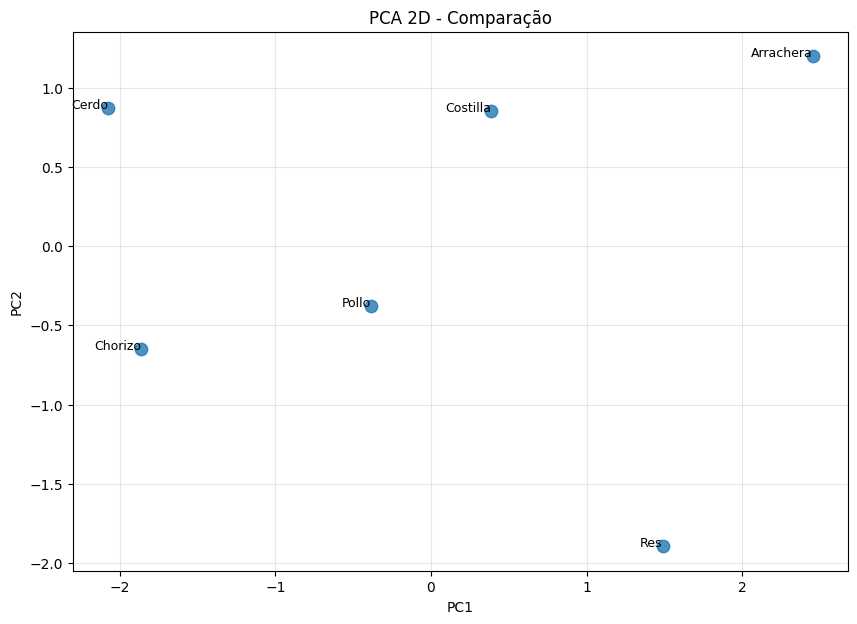

In [59]:
plt.figure(figsize=(10, 7))

plt.scatter(
    dados_analise["PC1"],
    dados_analise["PC2"],
    s=80,
    alpha=0.8
)

for i, produto in enumerate(dados_analise["producto"]):
    plt.text(
        dados_analise["PC1"].iloc[i],
        dados_analise["PC2"].iloc[i],
        produto,
        fontsize=9,
        ha="right"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D - Comparação")
plt.grid(True, alpha=0.3)
plt.show()

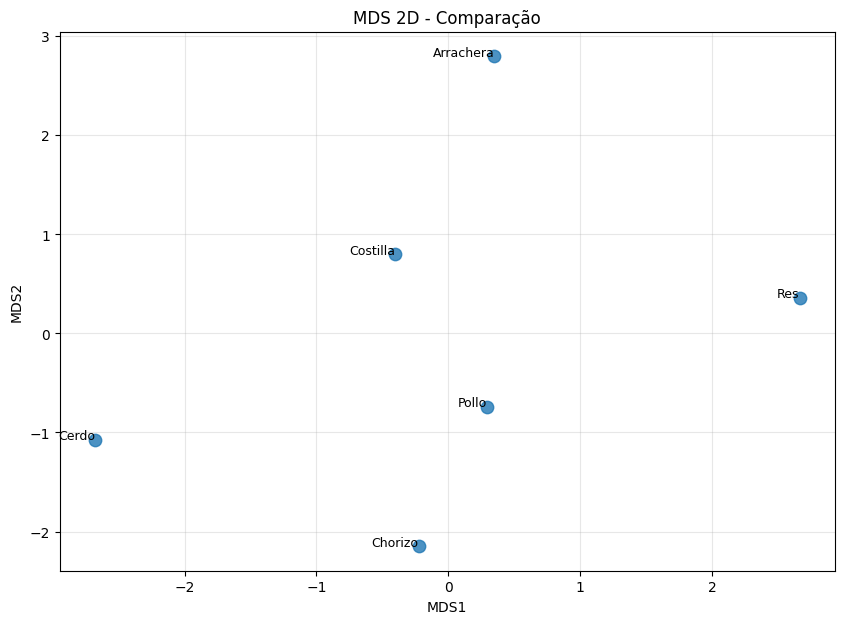

In [60]:
plt.figure(figsize=(10, 7))

plt.scatter(
    dados_analise["MDS1"],
    dados_analise["MDS2"],
    s=80,
    alpha=0.8
)

for i, produto in enumerate(dados_analise["producto"]):
    plt.text(
        dados_analise["MDS1"].iloc[i],
        dados_analise["MDS2"].iloc[i],
        produto,
        fontsize=9,
        ha="right"
    )

plt.xlabel("MDS1")
plt.ylabel("MDS2")
plt.title("MDS 2D - Comparação")
plt.grid(True, alpha=0.3)
plt.show()

# **20. Tabela final para interpretação**

In [61]:
resultado_final = dados_analise[
    [
        "producto",
        "quantidade_total",
        "receita_total",
        "preco_medio",
        "numero_vendas",
        "lojas_diferentes",
        "meses_com_venda",
        "ticket_medio",
        "PC1",
        "PC2",
        "MDS1",
        "MDS2",
        "distancia_pca",
        "distancia_mds"
    ]
].sort_values("receita_total", ascending=False)

resultado_final

,producto,quantidade_total,receita_total,preco_medio,numero_vendas,lojas_diferentes,meses_com_venda,ticket_medio,PC1,PC2,MDS1,MDS2,distancia_pca,distancia_mds
0,Arrachera,12703.0,2684963.86,189.293973,589,5,13,4558.512496,2.451600,1.198681,0.348270,2.799212,2.728952,2.820794
3,Costilla,10645.0,2357888.39,190.432336,625,5,13,3772.621424,0.386450,0.850402,-0.401927,0.798187,0.934091,0.893671
6,Res,13093.0,2269407.83,178.718072,607,5,13,3738.727891,1.487478,-1.893682,2.663427,0.362012,2.408033,2.687916
5,Pollo,11833.0,1932176.59,188.179857,630,5,13,3066.946968,-0.387860,-0.377579,0.293099,-0.738303,0.541295,0.794354
2,Chorizo,9671.0,1683283.04,186.403836,636,5,13,2646.671447,-1.863801,-0.648327,-0.224048,-2.148250,1.973343,2.159902
1,Cerdo,8916.0,1554223.54,187.878049,574,5,13,2707.706516,-2.073868,0.870506,-2.678821,-1.072857,2.249157,2.885672


In [62]:
resultado_final.to_csv("resultado_pca_mds_acougue.csv", index=False)

print("Arquivo salvo como resultado_pca_mds_acougue.csv")

Arquivo salvo como resultado_pca_mds_acougue.csv


# Resumo da variância explicada

In [63]:
print("RESUMO DO PCA")
print("PC1 explicou:", round(variancia_explicada[0] * 100, 2), "% da variância.")
print("PC2 explicou:", round(variancia_explicada[1] * 100, 2), "% da variância.")
print("Juntos, PC1 e PC2 explicaram:", round(variancia_explicada.sum() * 100, 2), "% da variância.")

RESUMO DO PCA
PC1 explicou: 54.32 % da variância.
PC2 explicou: 23.56 % da variância.
Juntos, PC1 e PC2 explicaram: 77.88 % da variância.


# Variáveis mais importantes

In [64]:
print("VARIÁVEIS MAIS IMPORTANTES NO PC1")
print(loadings["PC1"].abs().sort_values(ascending=False))

print("\nVARIÁVEIS MAIS IMPORTANTES NO PC2")
print(loadings["PC2"].abs().sort_values(ascending=False))

VARIÁVEIS MAIS IMPORTANTES NO PC1
ticket_medio        0.585008
receita_total       0.584421
quantidade_total    0.545703
preco_medio         0.104753
numero_vendas       0.086333
lojas_diferentes    0.000000
meses_com_venda     0.000000
Name: PC1, dtype: float64

VARIÁVEIS MAIS IMPORTANTES NO PC2
preco_medio         0.815240
numero_vendas       0.392360
quantidade_total    0.322412
ticket_medio        0.224747
receita_total       0.164244
lojas_diferentes    0.000000
meses_com_venda     0.000000
Name: PC2, dtype: float64


# Outliers encontrados

In [65]:
print("POSSÍVEIS OUTLIERS NO PCA")
display(outliers_pca[["producto", "distancia_pca"] + features])

print("\nPOSSÍVEIS OUTLIERS NO MDS")
display(outliers_mds[["producto", "distancia_mds"] + features])

POSSÍVEIS OUTLIERS NO PCA


,producto,distancia_pca,quantidade_total,receita_total,preco_medio,numero_vendas,lojas_diferentes,meses_com_venda,ticket_medio
0,Arrachera,2.728952,12703.0,2684963.86,189.293973,589,5,13,4558.512496



POSSÍVEIS OUTLIERS NO MDS


,producto,distancia_mds,quantidade_total,receita_total,preco_medio,numero_vendas,lojas_diferentes,meses_com_venda,ticket_medio
1,Cerdo,2.885672,8916.0,1554223.54,187.878049,574,5,13,2707.706516


# Produtos mais semelhantes pelo MDS

In [66]:
print("PRODUTOS MAIS SEMELHANTES SEGUNDO O MDS")
display(produtos_mais_semelhantes)

PRODUTOS MAIS SEMELHANTES SEGUNDO O MDS


,produto_1,produto_2,distancia_mds
10,Chorizo,Pollo,1.501796
12,Costilla,Pollo,1.686376
2,Arrachera,Costilla,2.137030
14,Pollo,Res,2.613263
5,Cerdo,Chorizo,2.679997
6,Cerdo,Costilla,2.947041
9,Chorizo,Costilla,2.951802
7,Cerdo,Pollo,2.990692
13,Costilla,Res,3.096230
4,Arrachera,Res,3.361532
